In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv ('/content/program_5_dataset.csv')

In [ ]:
df.head

<bound method NDFrame.head of      Unnamed: 0       Category  Age Sex   ALB    ALP    ALT    AST   BIL  \
0             1  0=Blood Donor   32   m  38.5   52.5    7.7   22.1   7.5   
1             2  0=Blood Donor   32   m  38.5   70.3   18.0   24.7   3.9   
2             3  0=Blood Donor   32   m  46.9   74.7   36.2   52.6   6.1   
3             4  0=Blood Donor   32   m  43.2   52.0   30.6   22.6  18.9   
4             5  0=Blood Donor   32   m  39.2   74.1   32.6   24.8   9.6   
..          ...            ...  ...  ..   ...    ...    ...    ...   ...   
610         611    3=Cirrhosis   62   f  32.0  416.6    5.9  110.3  50.0   
611         612    3=Cirrhosis   64   f  24.0  102.8    2.9   44.4  20.0   
612         613    3=Cirrhosis   64   f  29.0   87.3    3.5   99.0  48.0   
613         614    3=Cirrhosis   46   f  33.0    NaN   39.0   62.0  20.0   
614         615    3=Cirrhosis   59   f  36.0    NaN  100.0   80.0  12.0   

       CHE  CHOL   CREA    GGT  PROT  
0     6.93  3.23  

In [ ]:
df.describe()

,Unnamed: 0,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000
mean,308.000000,47.408130,41.622838,68.263529,28.493627,34.731648,11.396748,8.196634,5.368013,81.271987,39.533171,72.044137
std,177.679487,10.055105,5.775549,25.621364,25.436592,33.036087,19.673150,2.205657,1.123464,49.754620,54.661071,5.398234
min,1.000000,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,154.500000,39.000000,38.800000,52.950000,16.450000,21.600000,5.300000,6.935000,4.620000,67.000000,15.700000,69.300000
50%,308.000000,47.000000,41.900000,66.700000,23.000000,25.900000,7.300000,8.260000,5.310000,77.000000,23.300000,72.200000
75%,461.500000,54.000000,45.200000,79.300000,33.050000,32.900000,11.200000,9.590000,6.055000,88.000000,40.200000,75.400000
max,615.000000,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


In [ ]:
df.shape

(615, 14)

In [ ]:
df.isnull().sum()

Unnamed: 0     0
Category       0
Age            0
Sex            0
ALB            2
ALP           20
ALT            3
AST            2
BIL            0
CHE            0
CHOL          11
CREA           1
GGT            0
PROT           1
dtype: int64

In [ ]:
df.fillna(df.mean(), inplace=True)

<ipython-input-7-bf934754a5b1>:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.fillna(df.mean(), inplace=True)


In [ ]:
df.isnull().sum()

Unnamed: 0    0
Category      0
Age           0
Sex           0
ALB           0
ALP           0
ALT           0
AST           0
BIL           0
CHE           0
CHOL          0
CREA          0
GGT           0
PROT          0
dtype: int64

In [ ]:
df.dtypes

Unnamed: 0      int64
Category       object
Age             int64
Sex            object
ALB           float64
ALP           float64
ALT           float64
AST           float64
BIL           float64
CHE           float64
CHOL          float64
CREA          float64
GGT           float64
PROT          float64
dtype: object

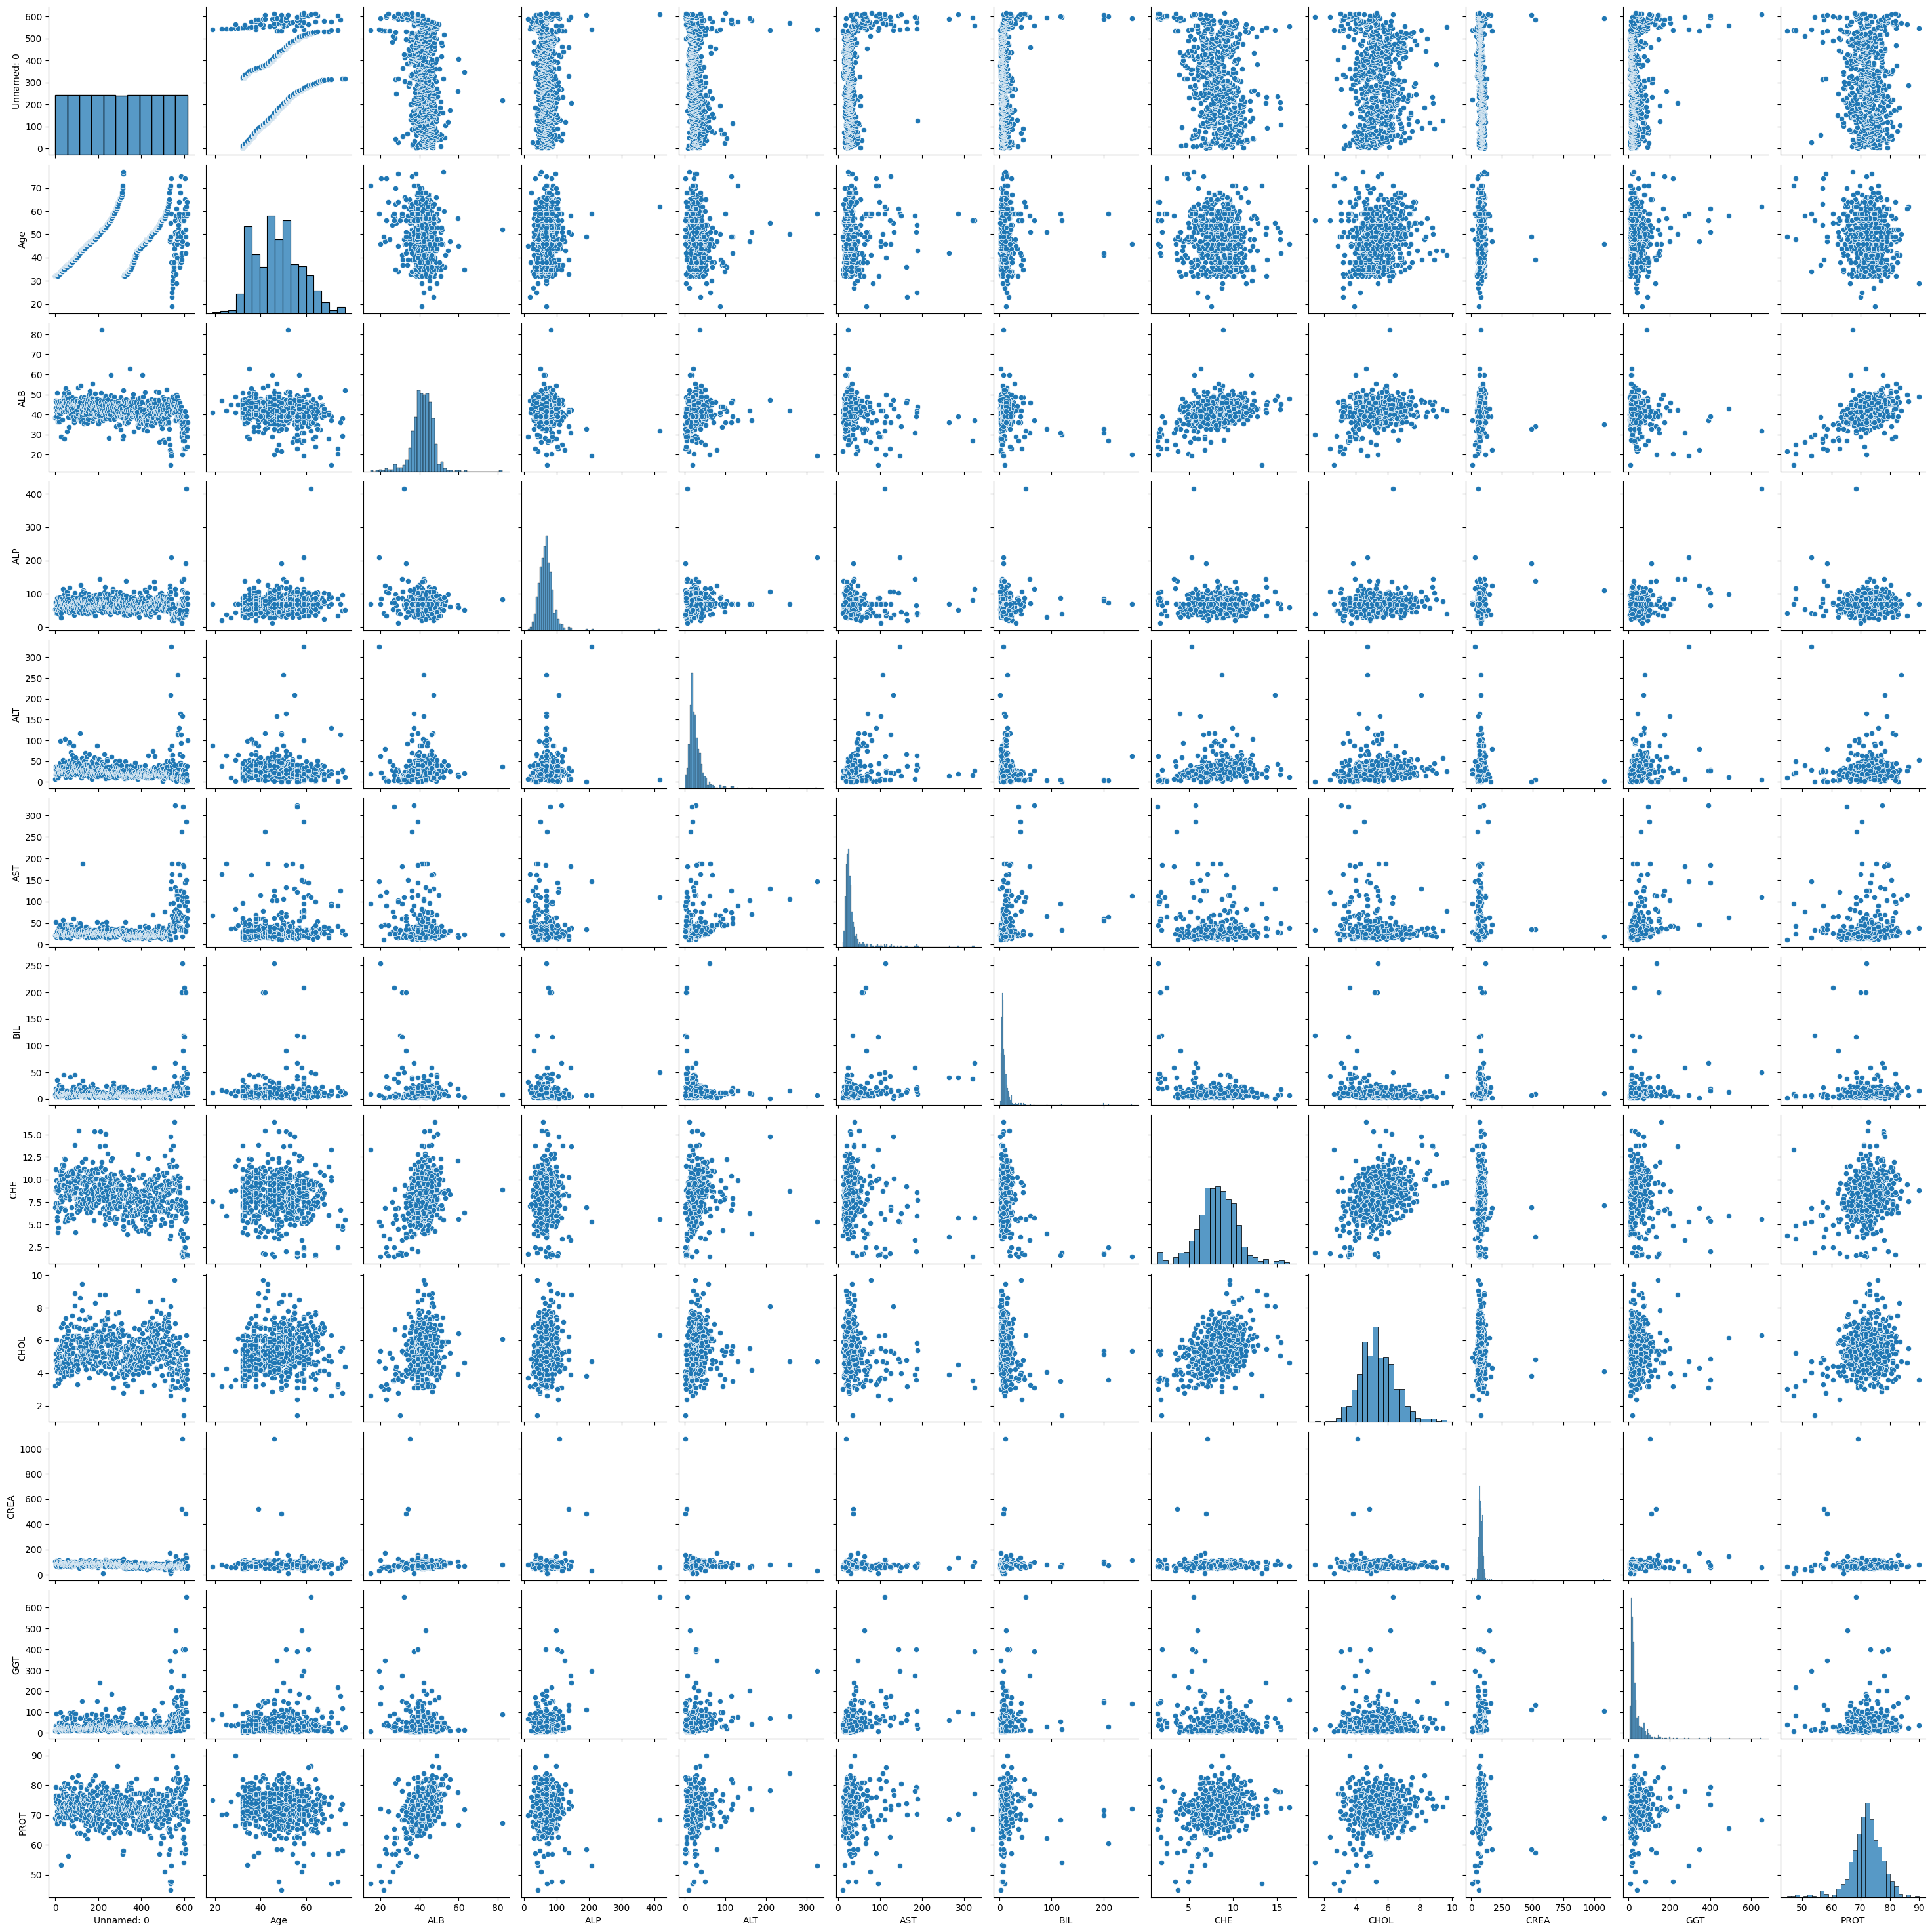

In [ ]:
sns.pairplot(df)

In [ ]:
#Linear Regression

In [ ]:
x = df[['CREA']].values
y = df['PROT'].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Data Points')
plt.plot(x, fit_line, color='red', label='Linear Regression')

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot with Linear Regression')

# Show legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

In [ ]:
coefficient = model.coef_[0]
intercept = model.intercept_

print(f'Coefficient: {coefficient}')
print(f'Intercept: {intercept}')

Coefficient: -0.003914818664546755
Intercept: 72.25442086883274


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
y_train_pred = model.predict(x_train)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
n_train=len(y_train)
k_train =1
adj_r2_train = ((1 - r2_train) * (n_train - 1) / (n_train - k_train - 1))

print(f'Training Set Metrics:')
print(f'Mean Squared Error: {mse_train}')
print(f'R-squared: {r2_train}')
print(f'Train Adjusted R-squared: {adj_r2_train}')

y_test_pred = model.predict(x_test)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
n_test=len(y_test)
k_test =1
adj_r2_test = ((1 - r2_test) * (n_test - 1) / (n_test - k_test - 1))

print('\nTesting Set Metrics:')
print(f'Mean Squared Error: {mse_test}')
print(f'R-squared: {r2_test}')
print(f'Train Adjusted R-squared: {adj_r2_test}')

Training Set Metrics:
Mean Squared Error: 28.429575138093043
R-squared: 0.0016145243641475515
Train Adjusted R-squared: 1.0004229970147012

Testing Set Metrics:
Mean Squared Error: 31.659951887601213
R-squared: -0.01050893132580022
Train Adjusted R-squared: 1.0188602448078317


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Calculating the VIF
x=df[['ALB','ALP','ALT','AST','BIL','CHE','CHOL','CREA','GGT']]

vif=pd.Series([variance_inflation_factor(x.values,idx)
    for idx in range(x.shape[1])],
    index=x.columns)

print(vif)

ALB     30.939391
ALP      9.894721
ALT      2.671327
AST      3.103881
BIL      1.572421
CHE     22.129342
CHOL    26.864335
CREA     3.746091
GGT      2.600775
dtype: float64


### Multiple Linear regression

In [ ]:
x_final = df[['ALT','AST','BIL','CREA','GGT']]
y_final = df['PROT']

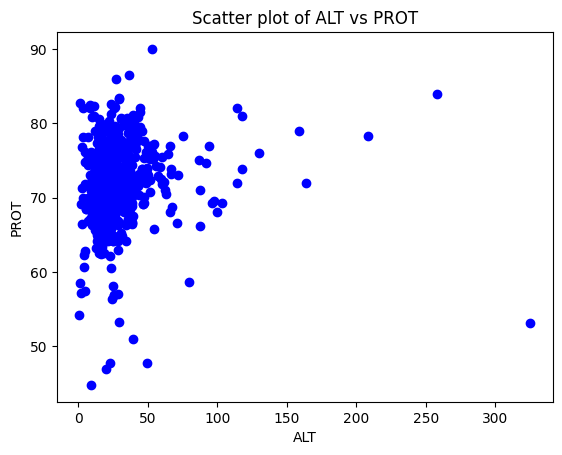

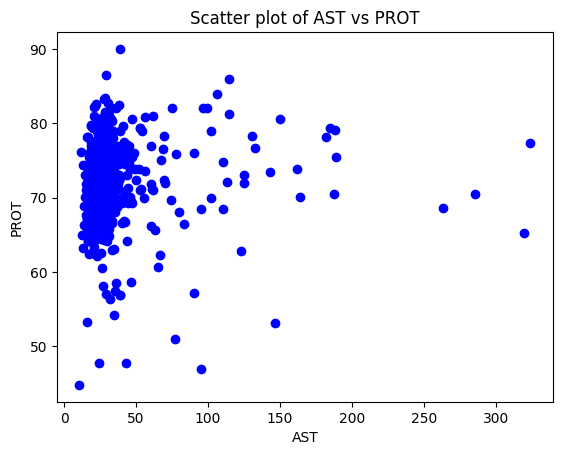

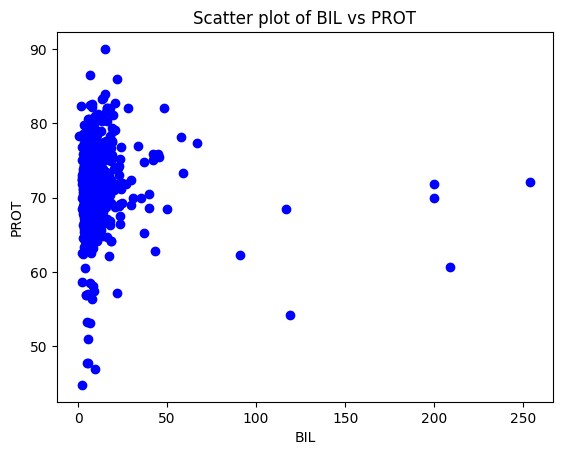

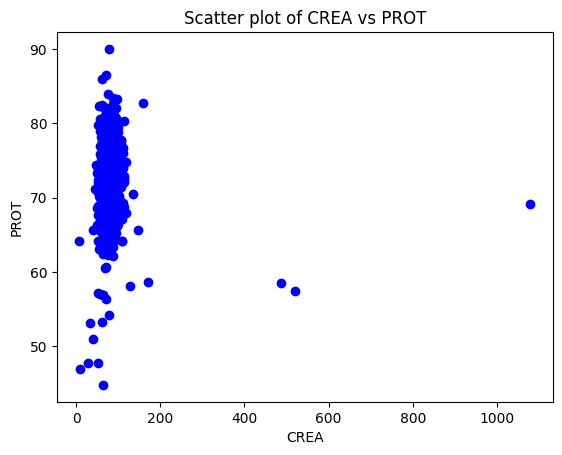

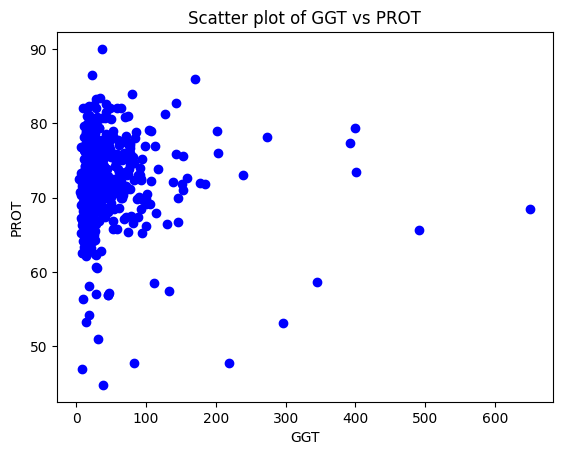

In [ ]:
for predictor in ['ALT','AST','BIL','CREA','GGT']:
    plt.scatter(df[predictor], df['PROT'], c='blue')
    plt.title(f'Scatter plot of {predictor} vs PROT')
    plt.xlabel(predictor)
    plt.ylabel('PROT')
    plt.show()

In [ ]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(x_final, y_final, test_size=0.2, random_state=42)

In [ ]:
model1=LinearRegression()

model1.fit(x_final, y_final)

print("Intercept:",model1.intercept_,'\nCoefficeints',model1.coef_)

Intercept: 71.68390116399328 
Coefficeints [ 0.0184502   0.00989699 -0.01218313 -0.00210058 -0.00505018]


In [ ]:
Y_train_pred = model1.predict(X_train1)
mse_train = mean_squared_error(Y_train1, Y_train_pred)
r2_train = r2_score(Y_train1, Y_train_pred)
n_train=len(Y_train1)
k_train =1
adj_r2_train = ((1 - r2_train) * (n_train - 1) / (n_train - k_train - 1))

print(f'Training Set Metrics:')
print(f'Mean Squared Error: {mse_train}')
print(f'R-squared: {r2_train}')
print(f'Train Adjusted R-squared: {adj_r2_train}')

Y_test_pred = model1.predict(X_test1)

mse_test = mean_squared_error(Y_test1, Y_test_pred)
r2_test = r2_score(Y_test1, Y_test_pred)
n_test=len(Y_test1)
k_test =1
adj_r2_test = ((1 - r2_test) * (n_test - 1) / (n_test - k_test - 1))

print('\nTesting Set Metrics:')
print(f'Mean Squared Error: {mse_test}')
print(f'R-squared: {r2_test}')
print(f'Train Adjusted R-squared: {adj_r2_test}')

Training Set Metrics:
Mean Squared Error: 28.374120603952793
R-squared: 0.0035619682205840775
Train Adjusted R-squared: 0.9984715787830474

Testing Set Metrics:
Mean Squared Error: 29.93507904772227
R-squared: 0.044544829219602455
Train Adjusted R-squared: 0.9633514945058554


In [ ]:
#Polynomial regression

In [ ]:
x_poly = df[['ALB','ALP','CHE','CHOL']]
y_poly = df['PROT']

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(x_poly, y_poly, test_size=0.34, random_state=42)


Results for Polynomial Degree 2:
Training Set:
Mean Squared Error: 15.466706327529495
R-squared: 0.4718517152623468
Adjusted R-squared: 0.5485138998303647

Test Set:
Mean Squared Error: 22.743614277376555
R-squared: 0.20654658629592493
Adjusted R-squared: 0.1451970955456099


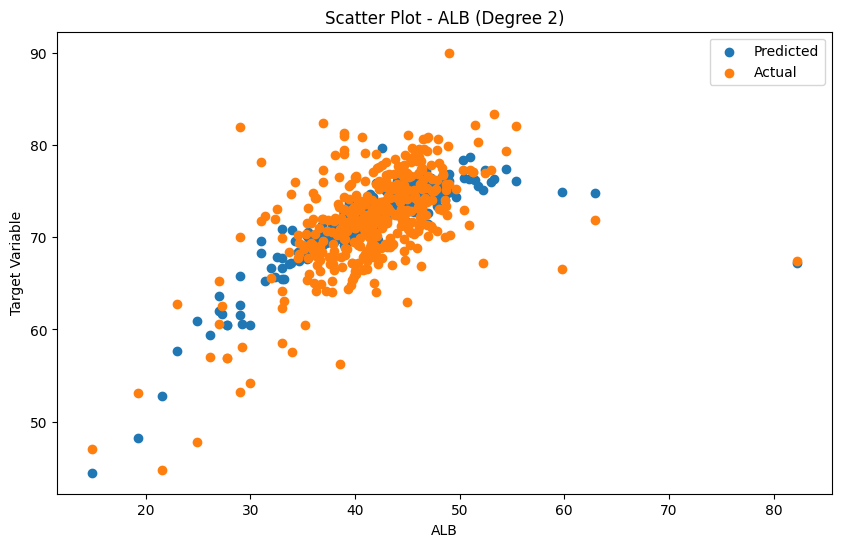

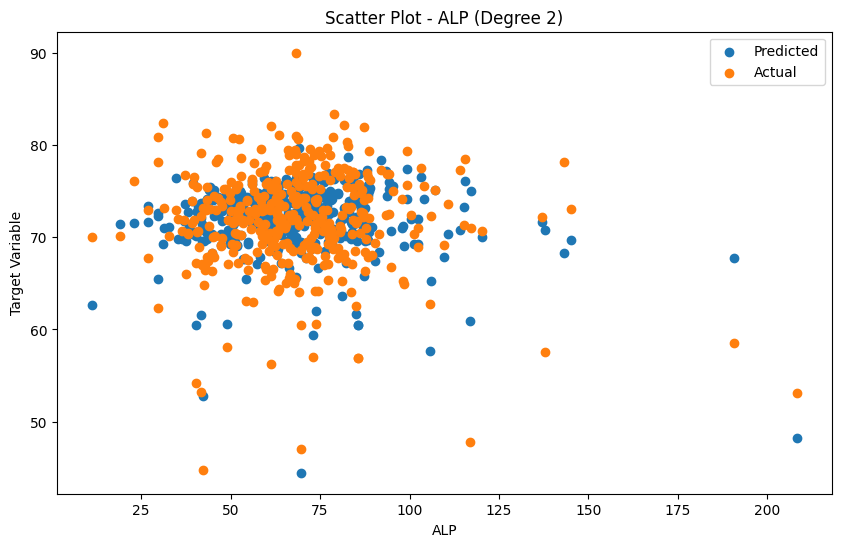

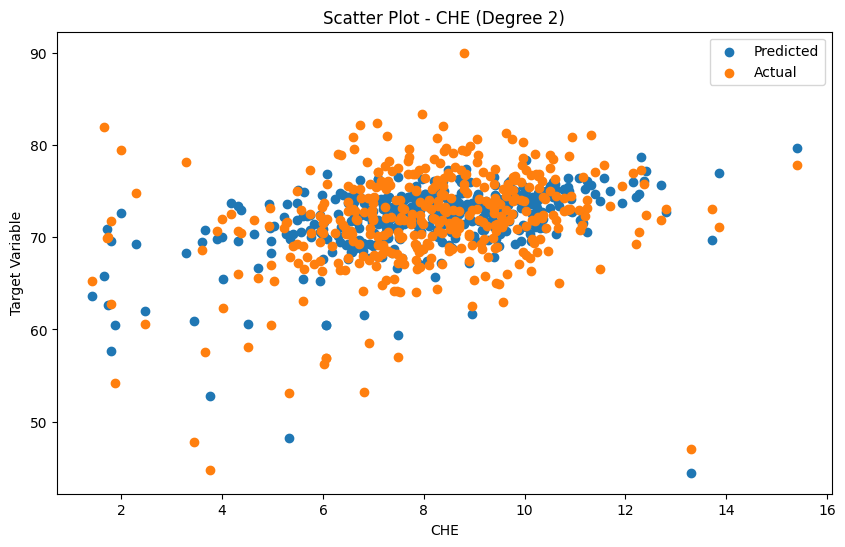

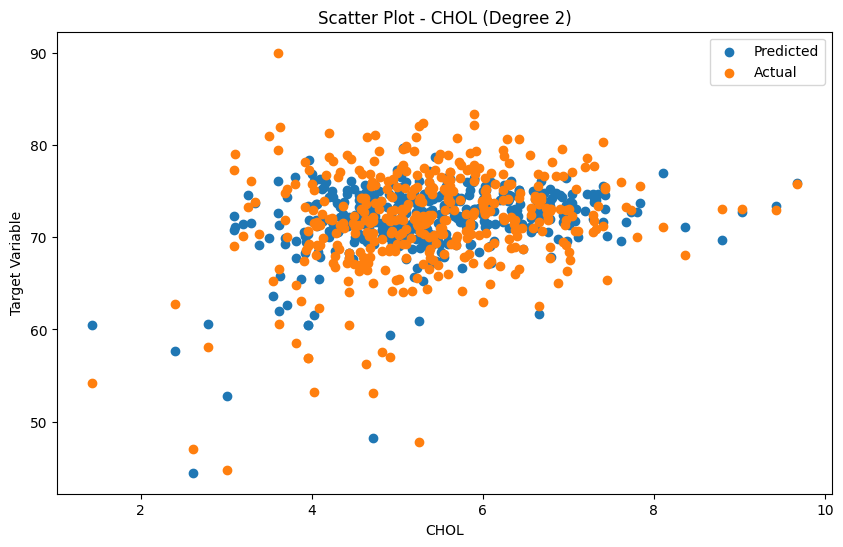


Results for Polynomial Degree 3:
Training Set:
Mean Squared Error: 14.941135668292711
R-squared: 0.4897986030034217
Adjusted R-squared: 0.5585944834325681

Test Set:
Mean Squared Error: 4008.0984405578515
R-squared: -138.82999145769207
Adjusted R-squared: -166.9567138773428


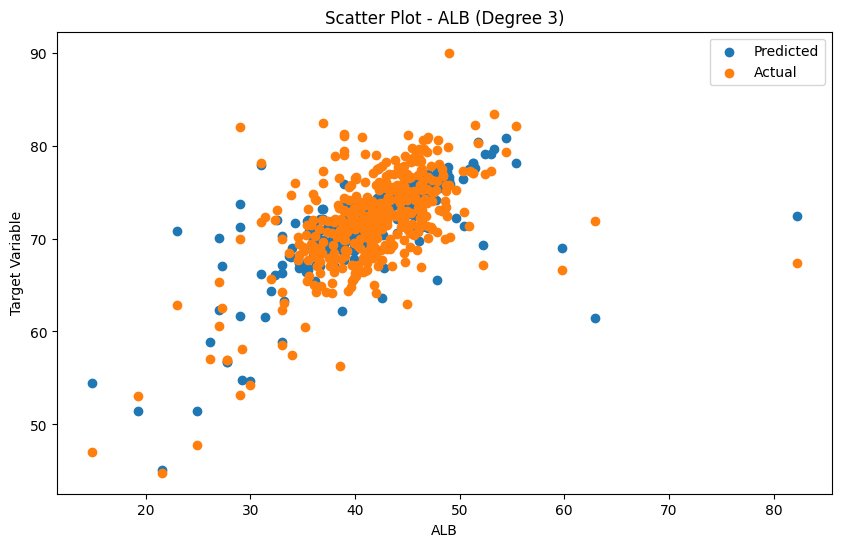

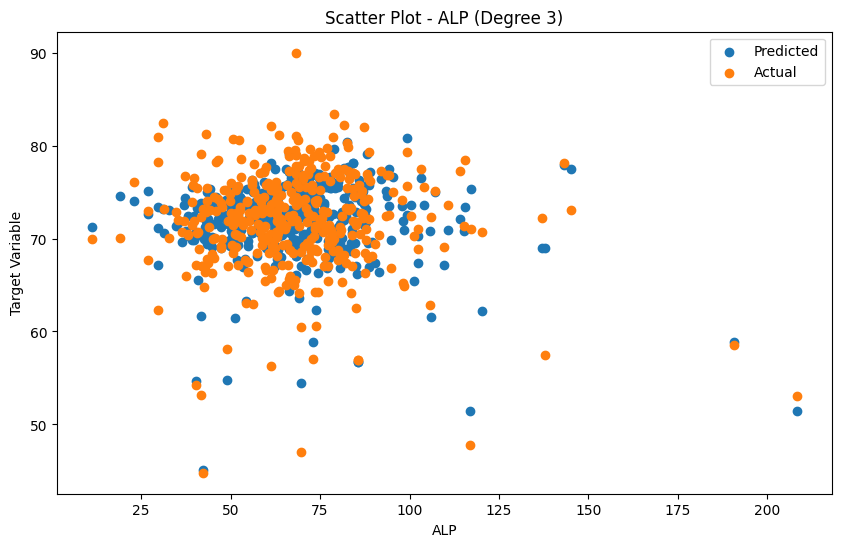

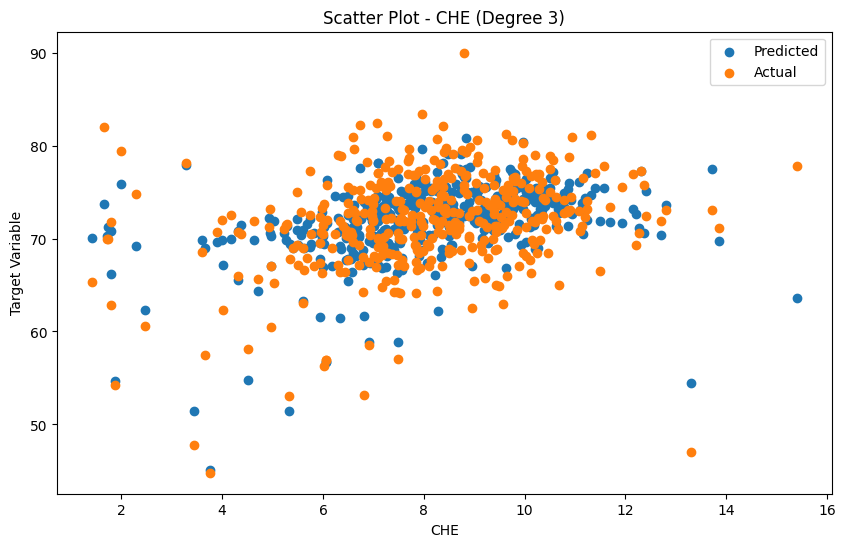

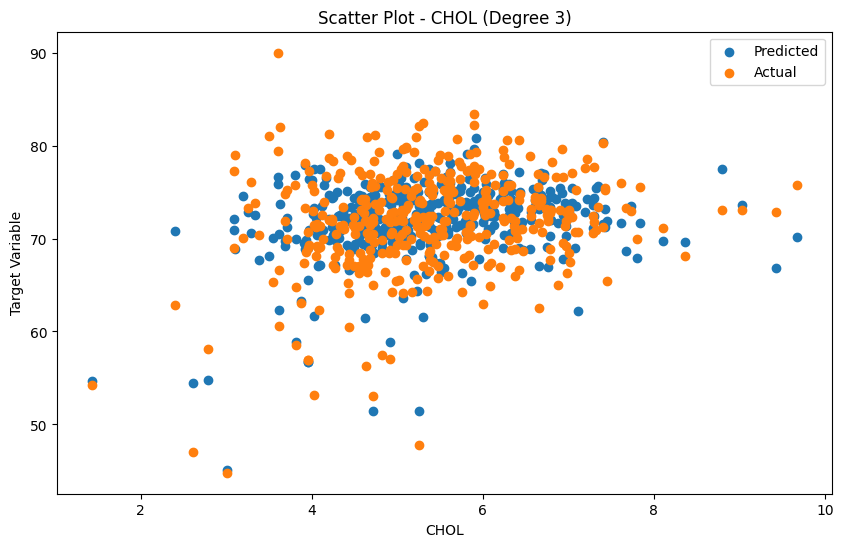


Results for Polynomial Degree 4:
Training Set:
Mean Squared Error: 13.880537361800734
R-squared: 0.5260153103299434
Adjusted R-squared: 0.5733227982835415

Test Set:
Mean Squared Error: 25510.15036424163
R-squared: -888.9691862408141
Adjusted R-squared: -1337.1551073692817


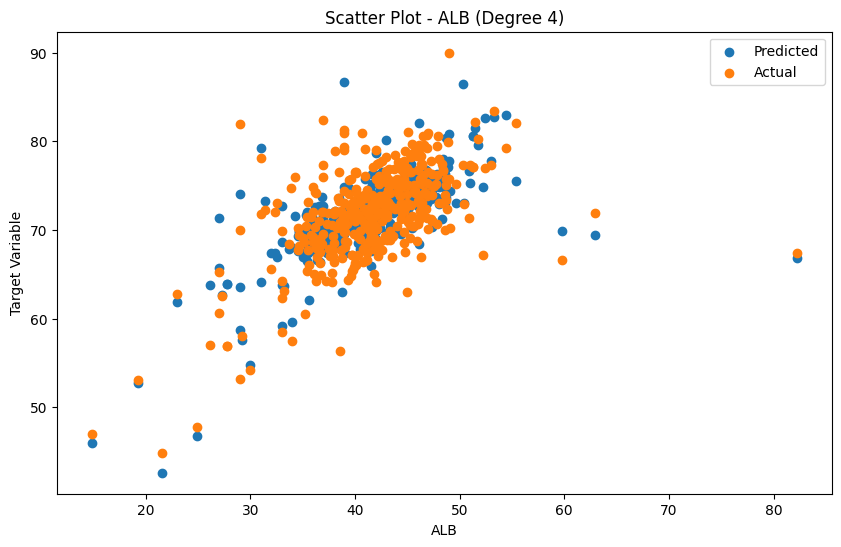

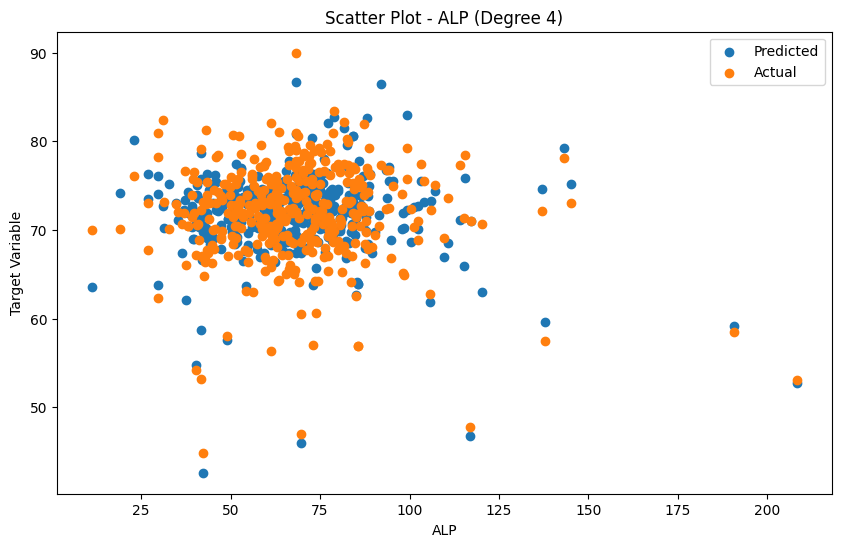

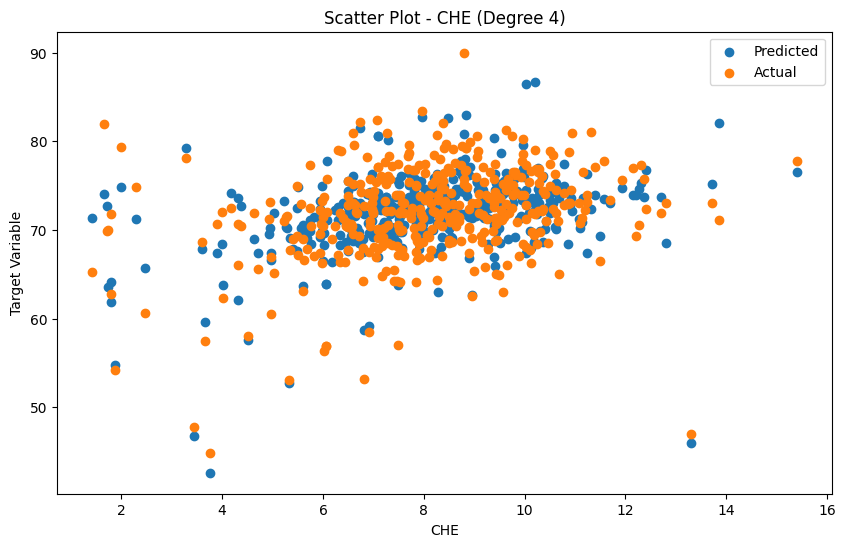

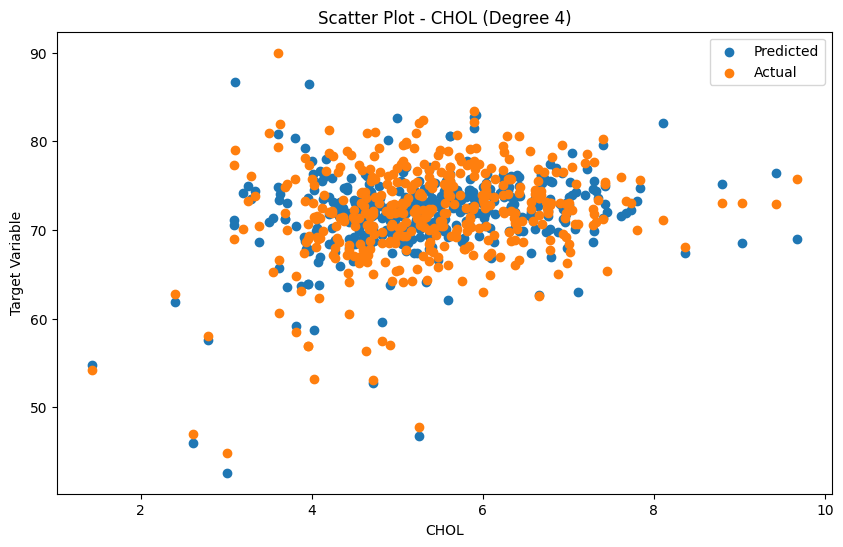

In [ ]:
from sklearn.preprocessing import  PolynomialFeatures

for degree in [2, 3, 4]:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_p = poly.fit_transform(X_train2)
    X_test_p = poly.transform(X_test2)

    # Fit the polynomial regression model
    model = LinearRegression()
    model.fit(X_train_p, y_train2)

    # Evaluate on the training set
    y_train_pred = model.predict(X_train_p)
    train_mse = mean_squared_error(y_train2, y_train_pred)
    train_r2 = r2_score(y_train2, y_train_pred)
    n_train = len(y_train2)
    p_train = X_train_p.shape[1]
    adj_r2_train = ((1 - train_r2) * (n_train - 1) / (n_train - p_train - 1))

    # Evaluate on the test set
    y_test_pred = model.predict(X_test_p)
    test_mse = mean_squared_error(y_test2, y_test_pred)
    test_r2 = r2_score(y_test2, y_test_pred)
    n_test = len(y_test2)
    p_test = X_test_p.shape[1]
    adj_r2_test = 1 - ((1 - test_r2) * (n_test - 1) / (n_test - p_test - 1))

    # Print the results for each degree
    print(f'\nResults for Polynomial Degree {degree}:')
    print('Training Set:')
    print(f'Mean Squared Error: {train_mse}')
    print(f'R-squared: {train_r2}')
    print(f'Adjusted R-squared: {adj_r2_train}')

    print('\nTest Set:')
    print(f'Mean Squared Error: {test_mse}')
    print(f'R-squared: {test_r2}')
    print(f'Adjusted R-squared: {adj_r2_test}')

    for i, feature in enumerate(X_train2.columns):
        plt.figure(figsize=(10, 6))
        plt.scatter(X_train2[feature], model.predict(X_train_p), label='Predicted')
        plt.scatter(X_train2[feature], y_train2, label='Actual')
        plt.xlabel(feature)
        plt.ylabel('Target Variable')
        plt.legend()
        plt.title(f'Scatter Plot - {feature} (Degree {degree})')
        plt.show()

In [ ]:
x_ridge =  df[['ALB','ALP','CHE','CHOL']]
y_ridge = df['PROT']

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
parameters={'alpha':[0.001,0.01,1,5,10,20,30,35,40,45,50,55,100,150]}
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)

In [ ]:
ridge_regressor.fit(x_ridge,y_ridge)

print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 150}
-21.283113786312143


In [ ]:
x_lasso =  df[['ALB','ALP','CHE','CHOL']]
y_lasso = df['PROT']

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()
parameters={'alpha':[0.001,0.01,1,5,10,20,30,35,40,45,50,55,100,150]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lasso_regressor.fit(x_lasso,y_lasso)

print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_lasso,y_lasso,test_size=0.33,random_state=2)

prediction_lasso=lasso_regressor.predict(x_test)
prediction_ridge=ridge_regressor.predict(x_test)

{'alpha': 0.01}
-21.330172180051402
